X shape: (100, 1)
X_b shape: (100, 2)
w_best shape: (2, 1)


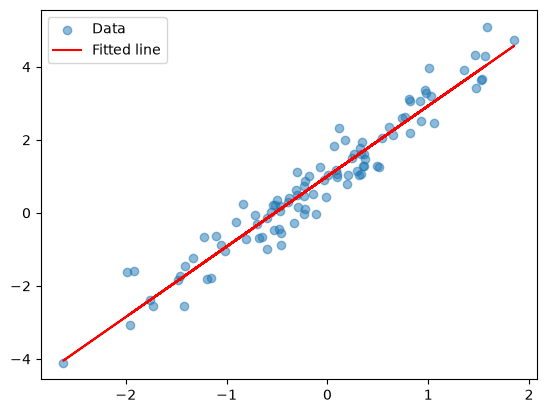

b=1.0037
w=1.9284
MSE=0.0000


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
m = 100
X= np.random.randn(m,1)
y= 2*X +1 + np.random.randn(m,1)* 0.5

print("X shape:",X.shape)

X_b= np.c_[np.ones((m,1)),X]
print("X_b shape:",X_b.shape)

w_best=np.linalg.inv(X_b.T@X_b)@X_b.T@y
print("w_best shape:",w_best.shape)

y_pred=X_b@w_best

plt.scatter(X,y,alpha=0.5,label="Data")
plt.plot(X,y_pred,color="red",label="Fitted line")
plt.legend()
plt.show()

print(f"b={w_best[0][0]:.4f}")
print(f"w={w_best[1][0]:.4f}")
print(f"MSE={np.mean(y_pred-y)**2:.4f}")


In [29]:
learning_rate = 0.002
epochs= 1000

w_gd=np.zeros((2,1))
loss_history=[]

for i in range(epochs):
    y_pred= X_b@ w_gd

    loss= np.mean((y_pred-y)**2)
    loss_history.append(loss)

    gradient =(2/m)*X_b.T@(y_pred-y)

    w_gd=w_gd-learning_rate*gradient

    if i% 100==0:
        print(f"Epoch{i:4d}:loss={loss:.6g},b={w_gd[0][0]:.4f},w={w_gd[1][0]:.4f}")

print(f"\n梯度下降最终:b={w_gd[0][0]:.4f},w={w_gd[1][0]:.4f}")
print(f"正规方程结果:b={w_best[0][0]:.4f},w={w_best[1][0]:.4f}")
print(f"真实值:     b=1.0000,w=2.0000")

Epoch   0:loss=3.90279,b=0.0032,w=0.0060
Epoch 100:loss=2.19306,b=0.2774,w=0.5182
Epoch 200:loss=1.27736,b=0.4760,w=0.8942
Epoch 300:loss=0.78687,b=0.6201,w=1.1701
Epoch 400:loss=0.524123,b=0.7246,w=1.3725
Epoch 500:loss=0.383364,b=0.8005,w=1.5209
Epoch 600:loss=0.307951,b=0.8557,w=1.6297
Epoch 700:loss=0.267547,b=0.8959,w=1.7095
Epoch 800:loss=0.245898,b=0.9251,w=1.7680
Epoch 900:loss=0.234299,b=0.9464,w=1.8109

梯度下降最终:b=0.9617,w=1.8420
正规方程结果:b=1.0037,w=1.9284
真实值:     b=1.0000,w=2.0000


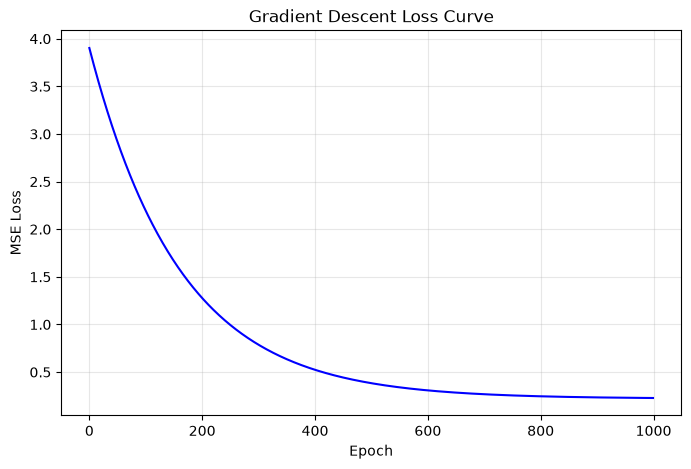

In [30]:
plt.figure(figsize=(8,5))
plt.plot(loss_history,color="blue")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent Loss Curve")
plt.grid(True,alpha=0.3)
plt.show()

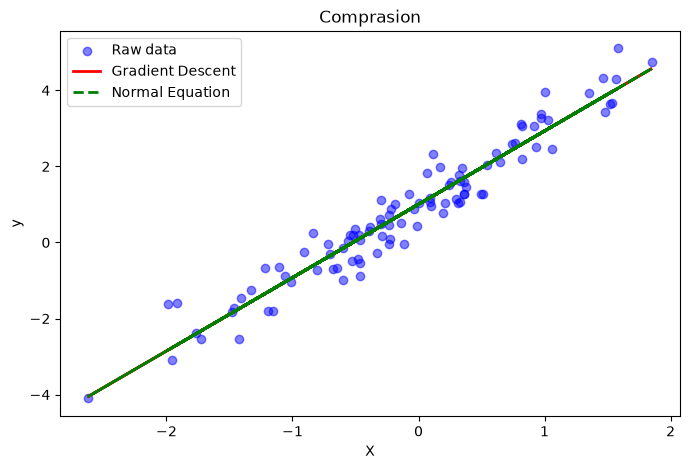

In [22]:
y_pred_gd=X_b@w_gd

plt.figure(figsize=(8,5))
plt.scatter(X,y,alpha=0.5,color='blue',label='Raw data')
plt.plot(X,y_pred_gd,color='red',linewidth=2,label='Gradient Descent')
plt.plot(X,y_pred,color='green',linewidth=2,linestyle='--',label='Normal Equation')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Comprasion")
plt.show()
